In [7]:
# ==========================================================
# COM763 - Advanced Machine Learning
# Project: Email Spam Detection
# Student: Kosala Ranathunga
# ==========================================================

# ==========================
# Section 1 - Import Libraries
# ==========================

# Data handling
import pandas as pd
import numpy as np

# Text processing
import string
import re
import nltk

# Download NLTK resources (only needed once)
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Save model
import joblib

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ Libraries imported successfully!


In [10]:
# ==========================================================
# Section 2 - Load Dataset
# ==========================================================

# Load the dataset
df = pd.read_csv("spam.csv")

# Display the first five rows
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
# ==========================================================
# Section 3 - Explore Dataset
# ==========================================================

# Display the shape of the dataset
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns)

# Display information about the dataset
print("\nDataset Information:")
df.info()

Dataset Shape: (5572, 2)

Columns:
Index(['Category', 'Message'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [12]:
# ==========================================================
# Section 4 - Data Cleaning
# ==========================================================

# Rename the columns
df = df.rename(columns={
    'Category': 'Label',
    'Message': 'Email'
})

# Display the updated column names
print("Updated Columns:")
print(df.columns)

# Display the first five rows
df.head()

Updated Columns:
Index(['Label', 'Email'], dtype='object')


,Label,Email
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
# Check for missing values

print(df.isnull().sum())

Label    0
Email    0
dtype: int64


In [14]:
# Check duplicate records

print("Duplicate Emails:", df.duplicated().sum())

Duplicate Emails: 415


In [15]:
# Remove duplicate emails

df = df.drop_duplicates()

print("New Dataset Shape:", df.shape)

New Dataset Shape: (5157, 2)


In [16]:
# ==========================================================
# Section 5 - Exploratory Data Analysis (EDA)
# ==========================================================

# Count Spam and Ham emails
print(df['Label'].value_counts())

Label
ham     4516
spam     641
Name: count, dtype: int64


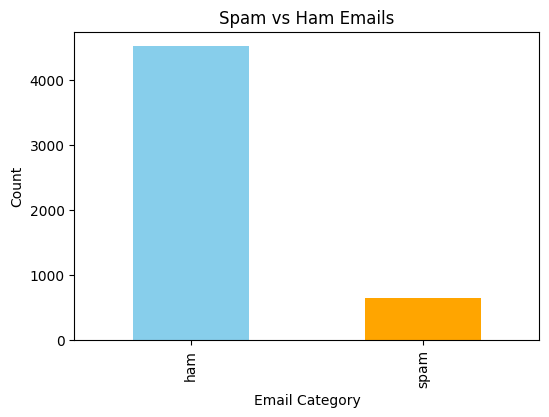

In [17]:
# Visualize Spam vs Ham

plt.figure(figsize=(6,4))

df['Label'].value_counts().plot(
    kind='bar',
    color=['skyblue', 'orange']
)

plt.title("Spam vs Ham Emails")
plt.xlabel("Email Category")
plt.ylabel("Count")

plt.show()

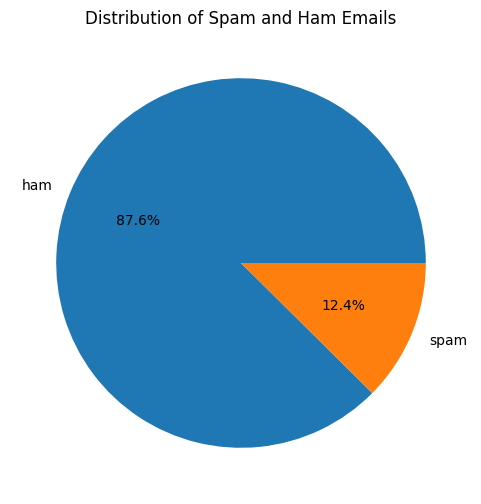

In [18]:
# Pie Chart

df['Label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Distribution of Spam and Ham Emails")
plt.ylabel("")

plt.show()

In [19]:
# Create a new column with email length

df['Email_Length'] = df['Email'].apply(len)

df.head()

,Label,Email,Email_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [20]:
# Compare average email length

df.groupby('Label')['Email_Length'].mean()

,Email_Length
Label,
ham,70.869353
spam,137.118565


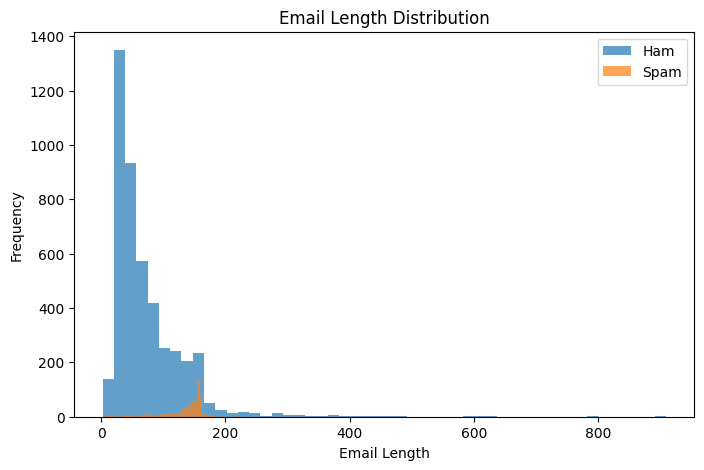

In [21]:
# Histogram of Email Length

plt.figure(figsize=(8,5))

plt.hist(
    df[df['Label']=='ham']['Email_Length'],
    bins=50,
    alpha=0.7,
    label='Ham'
)

plt.hist(
    df[df['Label']=='spam']['Email_Length'],
    bins=50,
    alpha=0.7,
    label='Spam'
)

plt.xlabel("Email Length")
plt.ylabel("Frequency")
plt.title("Email Length Distribution")

plt.legend()

plt.show()

In [29]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [30]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [31]:
# ==========================================================
# Section 6 - Text Preprocessing
# ==========================================================

ps = PorterStemmer()

In [32]:
def transform_text(text):

    # Convert to lowercase
    text = text.lower()

    # Tokenize words
    text = nltk.word_tokenize(text)

    y = []

    # Keep only letters and numbers
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    # Remove stopwords and punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    # Apply stemming
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [33]:
transform_text("Congratulations! You have WON a FREE iPhone!!!")

'congratul free iphon'

In [34]:
# Create a new column with cleaned email text

df['Transformed_Email'] = df['Email'].apply(transform_text)

# Display the first five rows

df.head()

,Label,Email,Email_Length,Transformed_Email
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,49,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah think goe usf live around though


In [35]:
# Convert labels to numbers
# ham = 0
# spam = 1

df['Label'] = df['Label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,Label,Email,Email_Length,Transformed_Email
0,0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah think goe usf live around though


In [36]:
# Create TF-IDF Vectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['Transformed_Email']).toarray()

y = df['Label']

In [37]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (4125, 3000)
Testing Data: (1032, 3000)


In [38]:
# Train the Multinomial Naive Bayes model

model = MultinomialNB()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [39]:
# ==========================================================
# Section 8 - Model Evaluation
# ==========================================================

# Predict on the test dataset
y_pred = model.predict(X_test)

In [40]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy: {:.2f}%".format(accuracy * 100))

Model Accuracy: 97.67%


In [41]:
# Display classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       896
           1       0.99      0.83      0.90       136

    accuracy                           0.98      1032
   macro avg       0.98      0.91      0.95      1032
weighted avg       0.98      0.98      0.98      1032



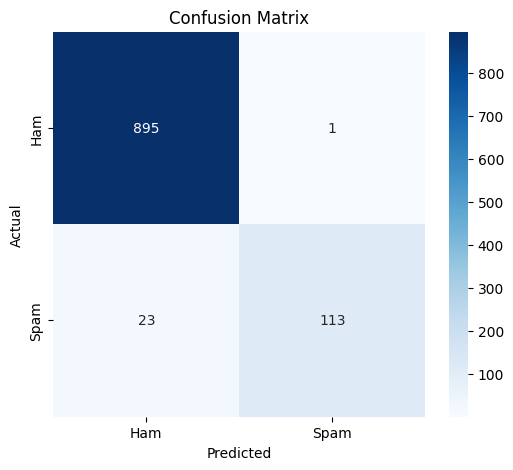

In [42]:
# Generate confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Ham','Spam'],
    yticklabels=['Ham','Spam']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [44]:
# ==========================================================
# Section 9 - Save Model
# ==========================================================

import joblib

# Save trained model
joblib.dump(model, "model.pkl")

# Save TF-IDF Vectorizer
joblib.dump(tfidf, "vectorizer.pkl")

print("Model and Vectorizer saved successfully!")

Model and Vectorizer saved successfully!
